<a href="https://colab.research.google.com/github/jnkharel2024/projects/blob/main/Sales_and_Revenue_Prediction_2_5_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction
In this notebook I explore the 'realistic_linear_regression_dataset.csv' dataset. The dataset includes sales revenue data along with associated features like production cost, marketing spend, and various indices. My goal is to uncover insights from the data using various visualization techniques and even build a regression predictor to estimate future sales revenue. The journey will include data exploration, cleaning, visualization, and predictive modeling with linear regression.

In [ ]:
import pandas as pd

In [ ]:
import matplotlib
matplotlib.use('Agg')

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

In [ ]:
# For regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# For permutation importance
from sklearn.inspection import permutation_importance

# Set plot style
sns.set(style='whitegrid')

print('Imports and settings are ready')

Imports and settings are ready


In [ ]:
# Install Kaggle
!pip install kaggle


In [ ]:
# Upload kaggle.json
from google.colab import files
files.upload()


Saving realistic_linear_regression_dataset.csv to realistic_linear_regression_dataset.csv


{'realistic_linear_regression_dataset.csv': b'ProductCategory,Region,CustomerSegment,IsPromotionApplied,ProductionCost,MarketingSpend,SeasonalDemandIndex,CompetitorPrice,CustomerRating,EconomicIndex,StoreCount,SalesRevenue\nFurniture,East,High Income,Yes,536.0515214944497,189.27781080837988,1.1596114607913504,220.83135101748326,4.0356071036660595,146.22575729638726,52,2293.1437065100836\nToys,West,High Income,No,352.7013612258245,255.9214966465702,1.5453660672011096,467.2171749709735,4.106804129160162,104.26130441957444,35,1640.4543681511007\nElectronics,South,High Income,No,618.9891053874991,277.39935268373694,1.671902161767941,363.62326087765325,4.021775188715999,77.22075234804215,44,2173.08602274384\nFurniture,West,Middle Income,Yes,339.959643824213,153.55769914936158,1.4082442202109704,209.85362080262033,4.148890481585323,128.27745545860014,15,1672.60885700909\nFurniture,West,Middle Income,Yes,477.95138458325886,155.81447820515925,2.177300527179014,274.85995033600994,4.913781626036

In [ ]:
import pandas as pd
df = pd.read_csv("realistic_linear_regression_dataset.csv")
df.head()

,ProductCategory,Region,CustomerSegment,IsPromotionApplied,ProductionCost,MarketingSpend,SeasonalDemandIndex,CompetitorPrice,CustomerRating,EconomicIndex,StoreCount,SalesRevenue
0,Furniture,East,High Income,Yes,536.051521,189.277811,1.159611,220.831351,4.035607,146.225757,52,2293.143707
1,Toys,West,High Income,No,352.701361,255.921497,1.545366,467.217175,4.106804,104.261304,35,1640.454368
2,Electronics,South,High Income,No,618.989105,277.399353,1.671902,363.623261,4.021775,77.220752,44,2173.086023
3,Furniture,West,Middle Income,Yes,339.959644,153.557699,1.408244,209.853621,4.148890,128.277455,15,1672.608857
4,Furniture,West,Middle Income,Yes,477.951385,155.814478,2.177301,274.859950,4.913782,111.309643,61,2443.222482


In [ ]:
# Data Loading and Exploration
import pandas as pd

df = pd.read_csv("realistic_linear_regression_dataset.csv")
df.head()


,ProductCategory,Region,CustomerSegment,IsPromotionApplied,ProductionCost,MarketingSpend,SeasonalDemandIndex,CompetitorPrice,CustomerRating,EconomicIndex,StoreCount,SalesRevenue
0,Furniture,East,High Income,Yes,536.051521,189.277811,1.159611,220.831351,4.035607,146.225757,52,2293.143707
1,Toys,West,High Income,No,352.701361,255.921497,1.545366,467.217175,4.106804,104.261304,35,1640.454368
2,Electronics,South,High Income,No,618.989105,277.399353,1.671902,363.623261,4.021775,77.220752,44,2173.086023
3,Furniture,West,Middle Income,Yes,339.959644,153.557699,1.408244,209.853621,4.148890,128.277455,15,1672.608857
4,Furniture,West,Middle Income,Yes,477.951385,155.814478,2.177301,274.859950,4.913782,111.309643,61,2443.222482


In [ ]:
# Display first few rows
print('First five rows of the dataset:')
print(df.head())

# General information about the dataset
print('\nDataset information:')
print(df.info())

# Summary statistics for numeric columns
print('\nSummary statistics:')
print(df.describe())

First five rows of the dataset:
  ProductCategory Region CustomerSegment IsPromotionApplied  ProductionCost  \
0       Furniture   East     High Income                Yes      536.051521   
1            Toys   West     High Income                 No      352.701361   
2     Electronics  South     High Income                 No      618.989105   
3       Furniture   West   Middle Income                Yes      339.959644   
4       Furniture   West   Middle Income                Yes      477.951385   

   MarketingSpend  SeasonalDemandIndex  CompetitorPrice  CustomerRating  \
0      189.277811             1.159611       220.831351        4.035607   
1      255.921497             1.545366       467.217175        4.106804   
2      277.399353             1.671902       363.623261        4.021775   
3      153.557699             1.408244       209.853621        4.148890   
4      155.814478             2.177301       274.859950        4.913782   

   EconomicIndex  StoreCount  SalesRevenue

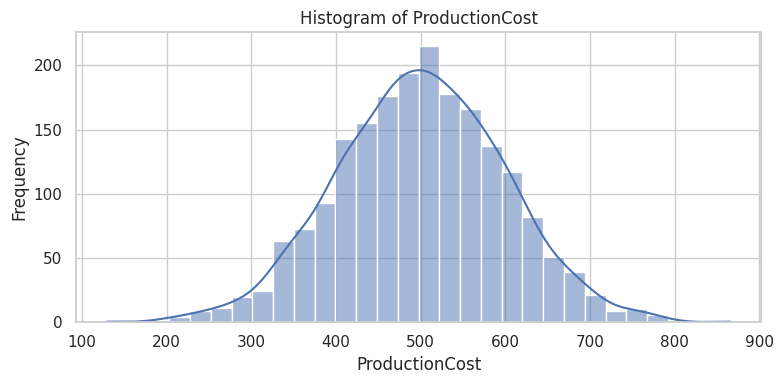

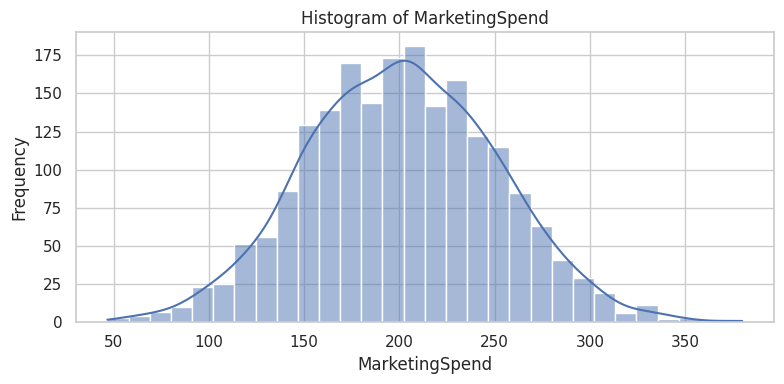

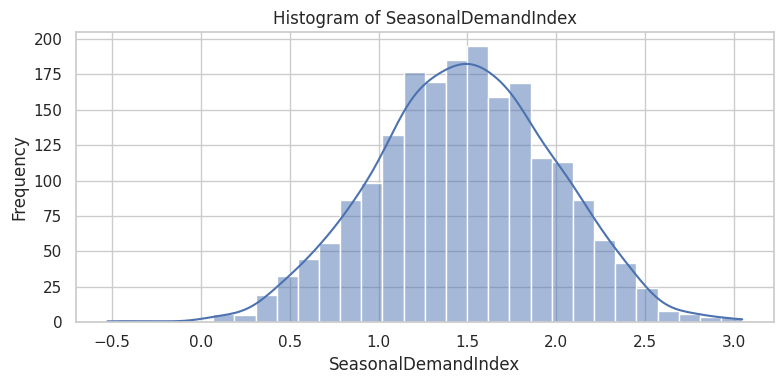

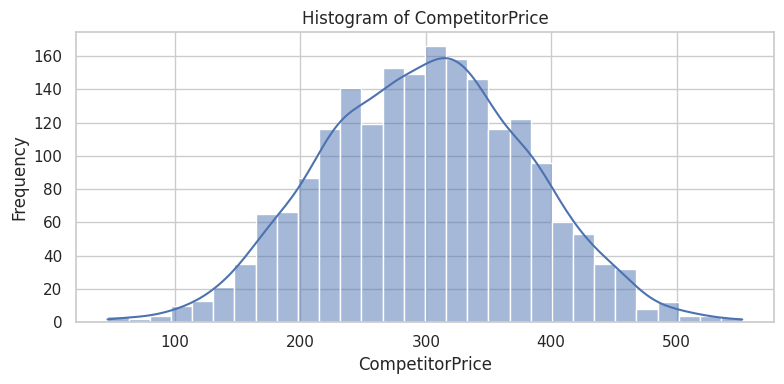

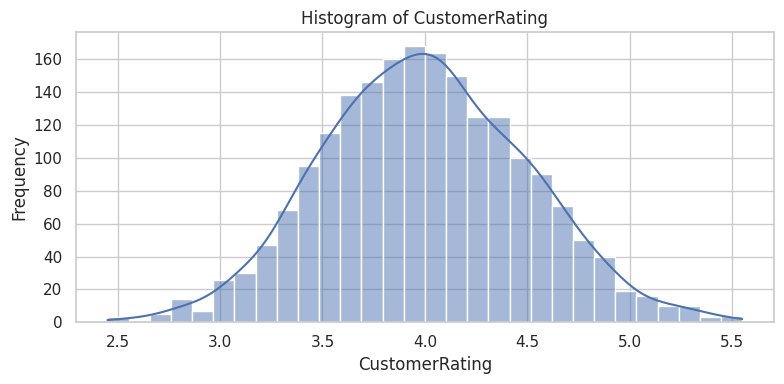

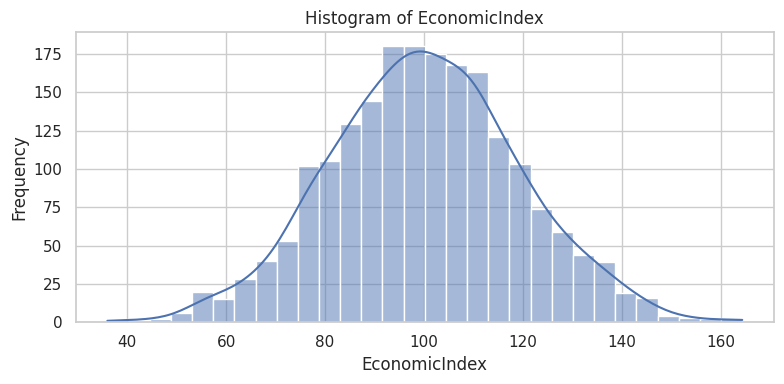

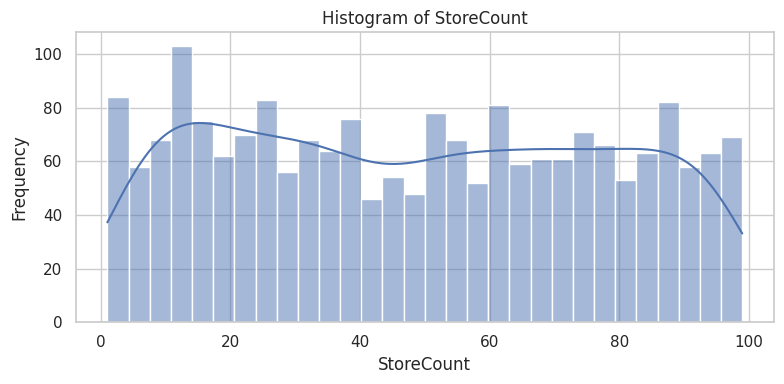

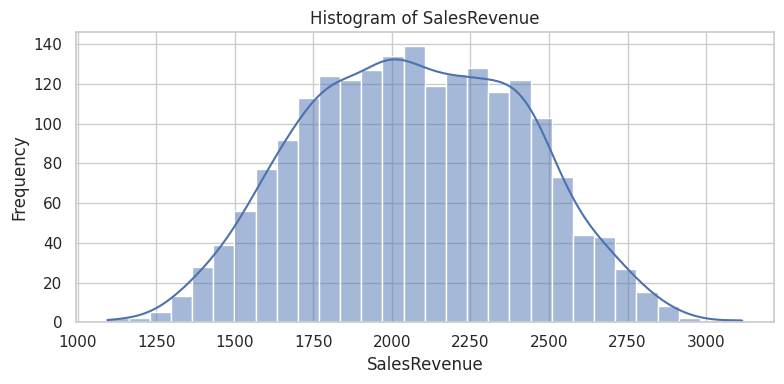

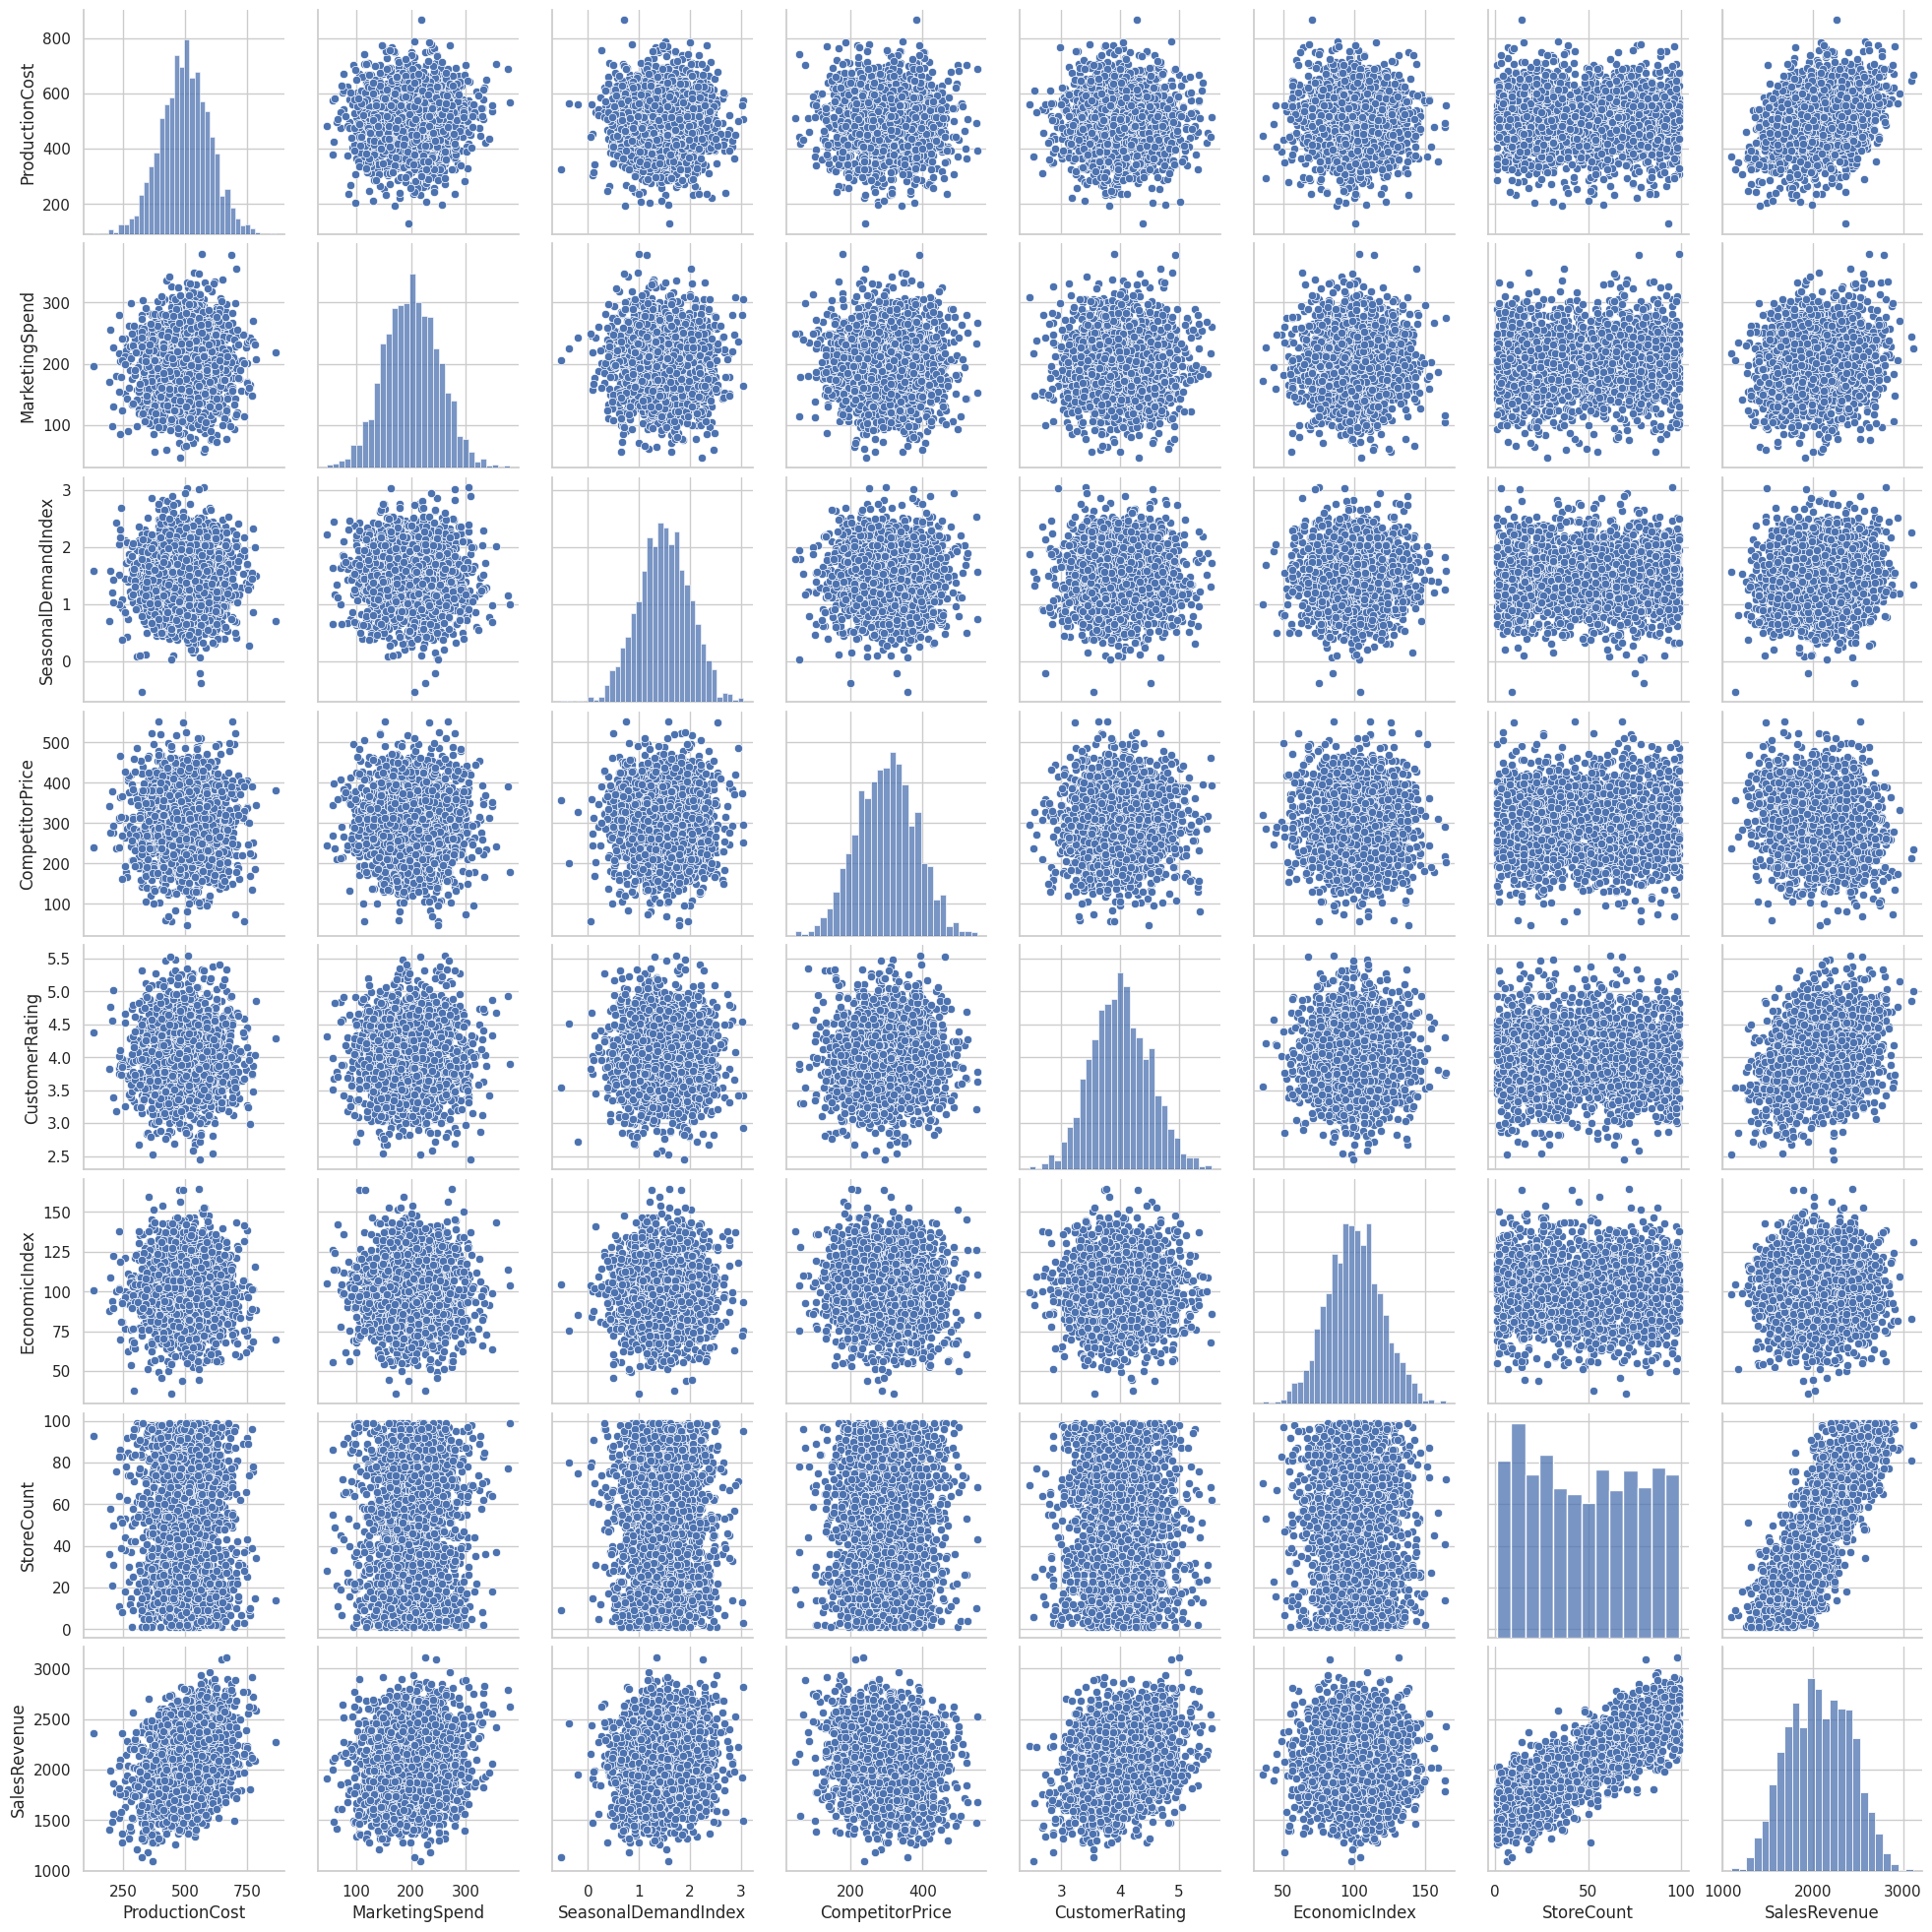

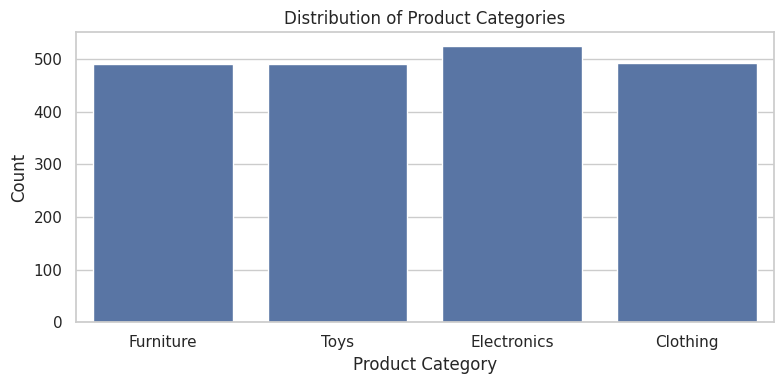

In [ ]:
# explorative
# Histograms for selected numeric columns
numeric_columns = ['ProductionCost', 'MarketingSpend', 'SeasonalDemandIndex', 'CompetitorPrice', 'CustomerRating', 'EconomicIndex', 'StoreCount', 'SalesRevenue']

for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Pair Plot for numeric variables (if there are enough variables to explore relationships)
sns.pairplot(df[numeric_columns])
plt.show()

# Pie chart (count plot) for a categorical variable: ProductCategory
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='ProductCategory')
plt.title('Distribution of Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#Exploratory Data Analysis

Let's dive into some exploratory visualizations to understand the data distributions and relationships between variables. The dataset contains both numerical and categorical variables. We will particularly focus on production cost, marketing spend, and seasonal indices as well as customer ratings to see how they relate to sales revenue.

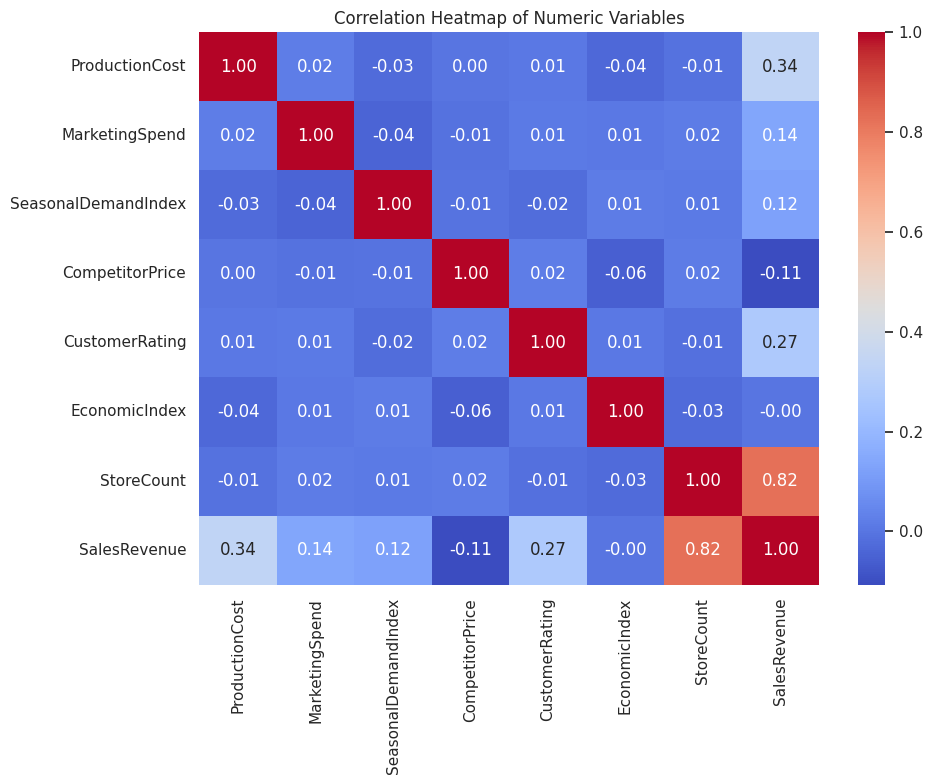

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap for numeric variables
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Variables')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric features for a correlation heatmap.')


##Data Cleaning and Preprocessing¶

Before modeling, it is important to handle non-numeric features and missing values if any. In this dataset, categorical variables such as ProductCategory, Region, CustomerSegment, and IsPromotionApplied will be encoded using one-hot encoding. This ensures that our regression model can handle these variables appropriately.

Note: If you encounter issues with encoding or missing values, it is advisable to inspect the data type conversions and ensure that all categories are treated consistently.

# New Section

# New Section

Linear Regression R² score on the test set: 0.9287


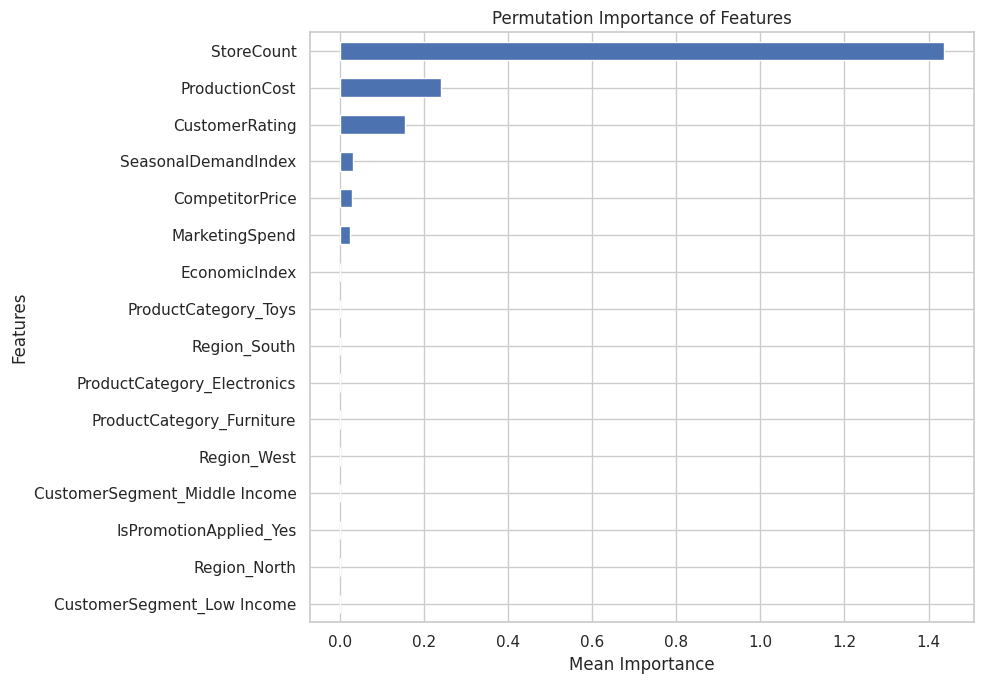

In [ ]:
# --- Clean, ready-to-run Linear Regression + Permutation Importance ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance


# ✅ Assumes you already have a DataFrame named `df`
# Example (uncomment if needed):
# df = pd.read_csv("your_file.csv")

target = "SalesRevenue"

# Clean column names (removes accidental spaces)
df = df.copy()
df.columns = df.columns.astype(str).str.strip()

# Ensure target exists
if target not in df.columns:
    raise ValueError(
        f"Target column '{target}' not found. Available columns: {df.columns.tolist()}"
    )

# Ensure target is numeric
if not pd.api.types.is_numeric_dtype(df[target]):
    df[target] = (
        df[target]
        .astype(str)
        .str.replace(r"[$,]", "", regex=True)
        .str.strip()
    )
    df[target] = pd.to_numeric(df[target], errors="coerce")

# Drop rows where target is missing
df = df.dropna(subset=[target])

# One-hot encode features (keeps target unchanged)
df_encoded = pd.get_dummies(df, drop_first=True)

# Split features/target
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Basic missing-value handling for features
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions + evaluation
y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Linear Regression R² score on the test set: {r2:.4f}")

# Permutation Importance
perm = permutation_importance(
    lr_model, X_test, y_test, n_repeats=10, random_state=42
)

feat_imp = (
    pd.Series(perm.importances_mean, index=X.columns)
    .sort_values(ascending=True)
)

# Plot
plt.figure(figsize=(10, 7))
feat_imp.plot(kind="barh")
plt.title("Permutation Importance of Features")
plt.xlabel("Mean Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Summary and Future Directions
In this notebook, we performed a comprehensive analysis of realistic sales revenue data. We started with exploratory visualizations including histograms, pair plots, and a correlation heatmap. Then we preprocessed the dataset by encoding categorical features and handling potential missing values. Finally, we built a linear regression model to predict SalesRevenue and evaluated its performance with an R² score. Permutation importance provided insight into which features were most influential.

Future analysis may include:

Experimenting with more advanced models such as Random Forest or Boosting methods for improved performance.
Conducting hyperparameter tuning to optimize model performance.
Analyzing time-series aspects if additional date-related data becomes available.
Exploring interaction effects between categorical and continuous features.